In [2]:

# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from IPython.display import Audio
import IPython

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML
    
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

import soundfile as sf
from urllib.request import urlopen
import io

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")





Waveshaping is one of the basic ways of distortion synthesis. In its simplest form it works like any overdrive effect: by limiting a signal with a non-linear shaping function, additional harmonics are created.


# Shaping Function

At the core of waveshaping is the **transfer function** or shaping function.
This transfer function is not exactly what we know from signals and systems ($H(f)$), but 
a **characteristic curve**, defining a mapping of input values to output values.

For a linear system, the transfer function is the identity line:



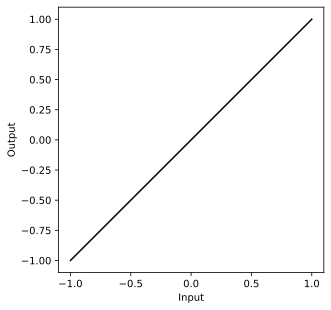

In [3]:
 
x    = np.linspace(-1,1,100)
y    = np.tanh(x*4)

p = plt.plot(x,x,'k')

plt.xlabel('Input')
plt.ylabel('Output')
plt.axis('square');


If signals stay within the boundaries ($-1...1$ in this example), the operation is linear:

$$f(a) + f(b) = f(a+b)$$

Within the limits the operation does not alter an input signal at all:


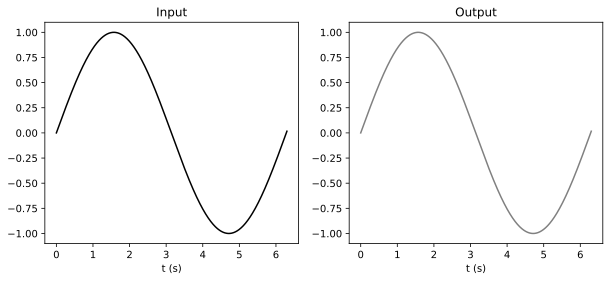

In [35]:
f = plt.figure(figsize=(10,4))

ax1  = f.add_subplot(121)
ax2 = f.add_subplot(122)

x = np.linspace(0,6.3,1000)

ax1.plot(x, np.sin(x),color='black')
ax1.set_title('Input')
ax1.set_xlabel('t (s)')

ax2.plot(x, np.sin(x),color='gray')
ax2.set_title('Output')
ax2.set_xlabel('t (s)')

plt.show()


----

The following example shows a simple tangential shaping function:

$$y=\mathrm{tanh}(g x)$$

For high pre-gain values, the function converges towards a step function and the output of a sinusoidal imput signal becomes a square wave.
The following plot shows the shaping function for $g=4$:

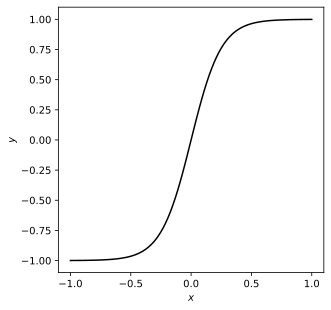

In [56]:
 
x    = np.linspace(-1,1,100)
y    = np.tanh(x*4)

p = plt.plot(x,y,'k')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.axis('square');

### Time Domain Comparison

In the time domain, the signal distortions are visible, but do not seem drastic:

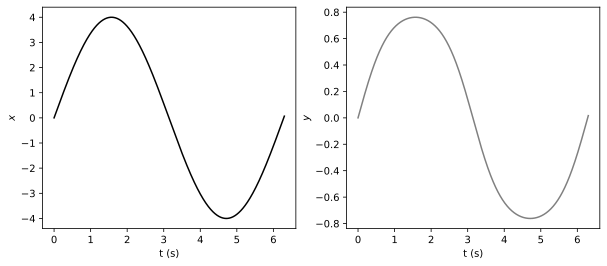

In [57]:
f = plt.figure(figsize=(10,4))

ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)

x = np.linspace(0,6.3,1000)

ax1.plot(x, 4*np.sin(x),color='black')
ax1.set_ylabel('$x$')
ax1.set_xlabel('t (s)')

ax2.plot(x, np.tanh(np.sin(x)),color='gray')
ax2.set_ylabel('$y$')
ax2.set_xlabel('t (s)')

plt.show()


### Frequency Domain Comparison

However, a frequency domain plot reveals that a significant amount of harmonics have been added:

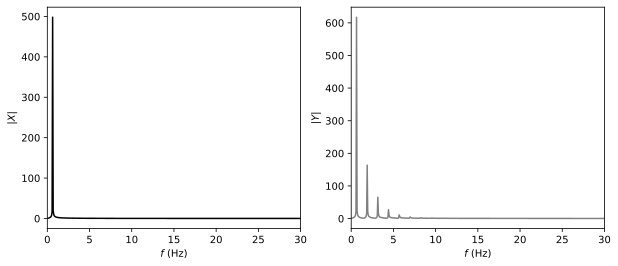

In [64]:
f = plt.figure(figsize=(10,4))

ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)

x = np.linspace(0,10*6.3,1000)

ax1.plot(x, abs(np.fft.fft(np.sin(x))),color='black')
ax1.set_ylabel('$|X|$')
ax1.set_xlabel('$f$ (Hz)')
ax1.set_xlim([0,30])

ax2.plot(x, abs(np.fft.fft(np.tanh(4*np.sin(x)))),color='gray')
ax2.set_ylabel('$|Y|$')
ax2.set_xlabel('$f$ (Hz)')
ax2.set_xlim([0,30])

plt.show()
